In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

In [2]:
def load_data(files, symbols):
    dfs = []
    for file, symbol in zip(files, symbols):
        df = pd.read_parquet(file)
        df['symbol'] = symbol  # Add the symbol column for each stock
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# List of files for multiple stocks and their symbols
files = ["data/2024_XIU.parquet", "data/2024_TD.parquet", "data/2024_BMO.parquet", "data/2024_BNS.parquet", "data/2024_RY.parquet"]
symbols = ["XIU", "TD", "BMO", "BNS", "RY"]  # Canadian market ETF and major Canadian banks

# Load data
df = load_data(files, symbols)

In [3]:
# Calculate daily returns
df['change_percent'] = df.groupby('symbol')['underlying_price'].pct_change() * 100

# Compute annualized volatility using daily returns by stock
volatility_by_stock = df.groupby('symbol')['change_percent'].std() * math.sqrt(250)  # 250 Canadian trading days
volatility_dict = volatility_by_stock.to_dict()

# Apply stock-specific volatility
df["sigma"] = df["symbol"].map(volatility_dict)

# Prepare dataframe with required parameters
df["T"] = df["dte"] / 365  # Time to maturity in years
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

# Filter for put options within 30-60 days to expiration
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]

In [4]:
# Define the binomial tree function
def binomial_tree_american_put(S0, K, r, sigma, T, M):
    dt = T / M
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    stock_prices = np.asarray([S0 * (u ** j) * (d ** (M - j)) for j in range(M + 1)])
    option_values = np.maximum(K - stock_prices, 0)

    # Backward induction
    for t in range(M - 1, -1, -1):
        option_values = discount * (p * option_values[1:] + (1 - p) * option_values[:-1])
        stock_prices = stock_prices[:-1] / u  # Move back one step
        option_values = np.maximum(option_values, K - stock_prices)  # Check early exercise

    return option_values[0]

# Compute binomial tree prices for each stock
def binomial_tree_batched(S0, K, r, sigma, T, M=50, batch_size=1000):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    L = len(S0)
    results = np.zeros(L)

    for i in range(0, L, batch_size):
        batch_end = min(i + batch_size, L)
        results[i:batch_end] = [
            binomial_tree_american_put(S0[j], K[j], r[j], sigma[j], T[j], M) for j in range(i, batch_end)
        ]

    return results

# Model Parameters
M = 50
batch_size = 1000

# Compute Binomial Tree Prices
puts_monthly["binomial_price"] = binomial_tree_batched(
    puts_monthly["S0"].values, puts_monthly["K"].values,
    puts_monthly["r"].values, puts_monthly["sigma"].values,
    puts_monthly["T"].values, M, batch_size
)

# Calculate moneyness (K/S ratio)
puts_monthly["moneyness"] = puts_monthly["K"] / puts_monthly["S0"]

# Calculate price difference and relative error
puts_monthly["price_diff"] = puts_monthly["binomial_price"] - puts_monthly["last_trade_price"]
puts_monthly["relative_error"] = puts_monthly["price_diff"] / puts_monthly["last_trade_price"]

# Calculate mispricing indicator (positive means potentially undervalued)
puts_monthly["mispricing"] = puts_monthly["binomial_price"] / puts_monthly["last_trade_price"] - 1

/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_36571/654737698.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["binomial_price"] = binomial_tree_batched(
/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_36571/654737698.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["moneyness"] = puts_monthly["K"] / puts_monthly["S0"]
/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_36571/654737698.py:55: SettingWithCopyWarning: 
A value is trying to be se

In [7]:
# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Create a scatter plot comparing model prices vs. market prices
def plot_model_vs_market():
    plt.figure(figsize=(10, 8))
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol]
        plt.scatter(
            symbol_data["last_trade_price"],
            symbol_data["binomial_price"],
            alpha=0.7,
            label=symbol,
            s=50
        )
    
    # Add a diagonal line (perfect predictions)
    max_val = max(puts_monthly["last_trade_price"].max(), puts_monthly["binomial_price"].max())
    plt.plot([0, max_val], [0, max_val], 'k--', label='Perfect Match')
    
    plt.title("Binomial Model vs. Market Prices for Canadian Bank Put Options", fontsize=14)
    plt.xlabel("Market Price", fontsize=12)
    plt.ylabel("Binomial Model Price", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add text explaining the interpretation
    plt.text(
        0.02, 0.98,
        "Points above line: Model predicts higher prices (potentially undervalued)\n"
        "Points below line: Model predicts lower prices (potentially overvalued)",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    return plt

# 2. Mispricing by moneyness
def plot_mispricing_by_moneyness():
    plt.figure(figsize=(10, 8))
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol]
        
        # Sort data by moneyness for better visualization
        symbol_data = symbol_data.sort_values("moneyness")
        
        plt.scatter(
            symbol_data["moneyness"],
            symbol_data["mispricing"] * 100,  # Convert to percentage
            alpha=0.7,
            label=symbol,
            s=50
        )
    
    # Add a horizontal line at 0 (no mispricing)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Add horizontal lines at +/- 10% (significant mispricing)
    plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='Buy Threshold (+10%)')
    plt.axhline(y=-10, color='r', linestyle='--', alpha=0.5, label='Sell Threshold (-10%)')
    
    plt.title("Option Mispricing by Moneyness for Canadian Bank Stocks", fontsize=14)
    plt.xlabel("Moneyness (Strike/Spot)", fontsize=12)
    plt.ylabel("Mispricing (%)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return plt

# 3. Find best trading opportunities
def identify_trading_opportunities(threshold=0.1):
    """Identify potential trading opportunities based on mispricing threshold"""
    # Find undervalued options (model price > market price)
    buy_opportunities = puts_monthly[puts_monthly["mispricing"] > threshold].sort_values(
        "mispricing", ascending=False
    ).head(5)
    
    # Find overvalued options (model price < market price)
    sell_opportunities = puts_monthly[puts_monthly["mispricing"] < -threshold].sort_values(
        "mispricing", ascending=True
    ).head(5)
    
    return buy_opportunities, sell_opportunities

# 4. Visualize top trading opportunities
def plot_top_opportunities():
    buy_opps, sell_opps = identify_trading_opportunities(threshold=0.1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    # Buy opportunities (undervalued)
    if not buy_opps.empty:
        buy_labels = [f"{row['symbol']} (K={row['K']:.1f})" for _, row in buy_opps.iterrows()]
        ax1.barh(buy_labels, buy_opps["mispricing"] * 100, color='green', alpha=0.7)
        ax1.set_title("Top 5 Undervalued Options (Buy Opportunities)", fontsize=12)
        ax1.set_xlabel("Mispricing (%)", fontsize=10)
        
        # Add actual values to the end of each bar
        for i, (_, row) in enumerate(buy_opps.iterrows()):
            ax1.text(
                row["mispricing"] * 100 + 0.5,  
                i,
                f"{row['mispricing']:.1%}",
                va='center'
            )
    else:
        ax1.text(0.5, 0.5, "No buy opportunities found", ha='center', va='center')
    
    # Sell opportunities (overvalued)
    if not sell_opps.empty:
        sell_labels = [f"{row['symbol']} (K={row['K']:.1f})" for _, row in sell_opps.iterrows()]
        ax2.barh(sell_labels, sell_opps["mispricing"] * 100, color='red', alpha=0.7)
        ax2.set_title("Top 5 Overvalued Options (Sell Opportunities)", fontsize=12)
        ax2.set_xlabel("Mispricing (%)", fontsize=10)
        
        # Add actual values to the end of each bar
        for i, (_, row) in enumerate(sell_opps.iterrows()):
            ax2.text(
                row["mispricing"] * 100 - 0.5,  
                i,
                f"{row['mispricing']:.1%}",
                va='center',
                ha='right'
            )
    else:
        ax2.text(0.5, 0.5, "No sell opportunities found", ha='center', va='center')
    
    plt.tight_layout()
    return plt

/Users/narainsriram/Desktop/ca_options_pricing/.venv/lib/python3.11/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
/Users/narainsriram/Desktop/ca_options_pricing/.venv/lib/python3.11/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


Model Performance Summary:
  Symbol  Volatility  Mean Abs Error  Mean Rel Error  Buy Opportunities  \
0    XIU    0.277046       23.465415             inf              31256   
1     TD    0.688488       71.804287             inf              15118   
2    BMO    0.688733      112.199624             inf              17245   
3    BNS    0.554916       59.268852             inf              16043   
4     RY    0.493753      128.399615             inf              17468   

   Sell Opportunities  Total Options  
0                   0          31256  
1                   0          15118  
2                   0          17245  
3                   0          16043  
4                   0          17468  

Key Findings:
1. Found 5 undervalued options that may be profitable to buy.
2. Found 0 overvalued options that may be profitable to sell.
3. Average model accuracy: -inf%
4. Stock with highest volatility: BMO
5. Stock with most trading opportunities: XIU


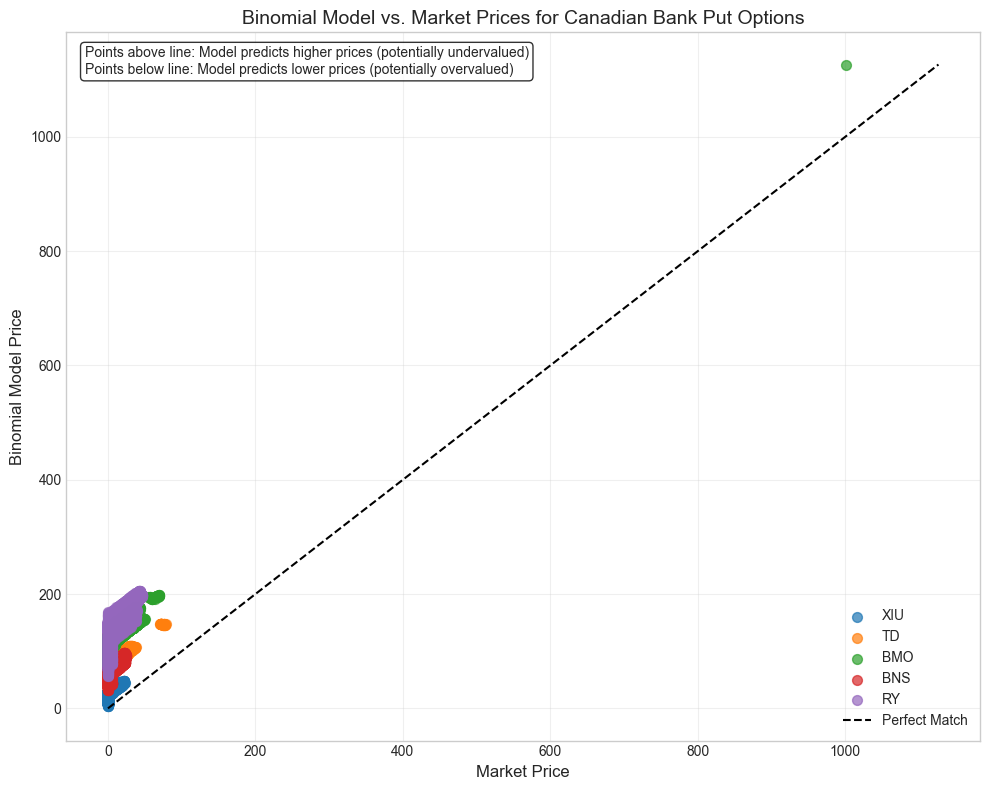

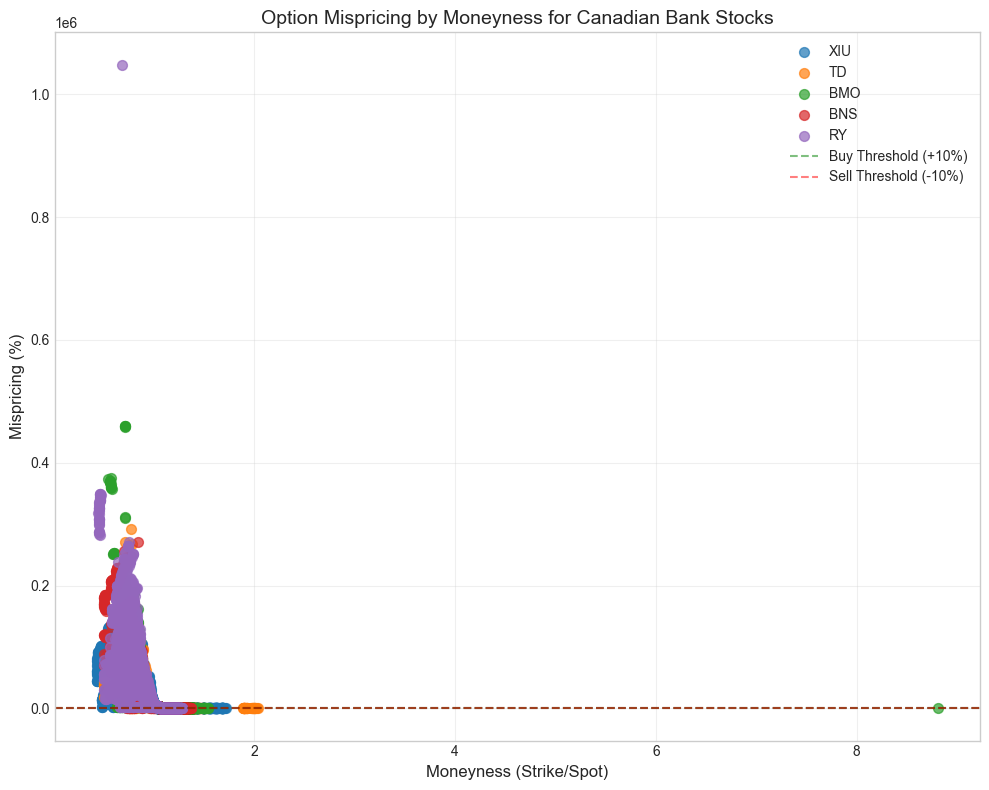

/Users/narainsriram/Desktop/ca_options_pricing/.venv/lib/python3.11/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


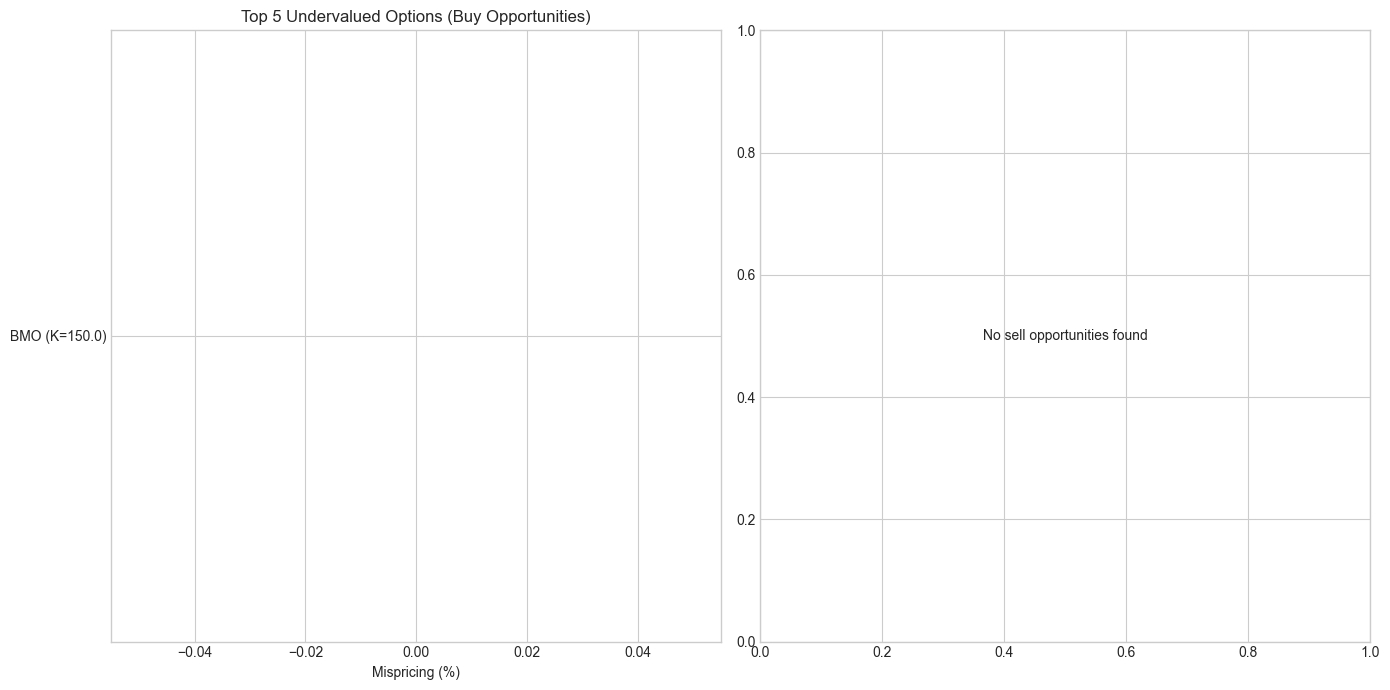

In [6]:
# 5. Generate summary statistics
def generate_performance_report():
    """Generate a summary report of the model performance and trading opportunities"""
    # Calculate statistics for each stock
    stats = []
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol]
        
        # Model accuracy metrics
        mean_abs_error = symbol_data["price_diff"].abs().mean()
        mean_rel_error = symbol_data["relative_error"].abs().mean()
        
        # Trading opportunities
        buy_count = sum(symbol_data["mispricing"] > 0.1)
        sell_count = sum(symbol_data["mispricing"] < -0.1)
        
        # Volatility
        volatility = volatility_dict[symbol]
        
        stats.append({
            "Symbol": symbol,
            "Volatility": volatility,
            "Mean Abs Error": mean_abs_error,
            "Mean Rel Error": mean_rel_error * 100,  # as percentage
            "Buy Opportunities": buy_count,
            "Sell Opportunities": sell_count,
            "Total Options": len(symbol_data)
        })
    
    return pd.DataFrame(stats)

# Execute all functions and generate the analysis
comparison_plot = plot_model_vs_market()
mispricing_plot = plot_mispricing_by_moneyness()
opportunities_plot = plot_top_opportunities()
performance_report = generate_performance_report()

# Display the performance report
print("Model Performance Summary:")
print(performance_report)

# Save plots
comparison_plot.savefig('model_vs_market.png', dpi=300, bbox_inches='tight')
mispricing_plot.savefig('mispricing_analysis.png', dpi=300, bbox_inches='tight')
opportunities_plot.savefig('trading_opportunities.png', dpi=300, bbox_inches='tight')

# Print out key findings
buy_opps, sell_opps = identify_trading_opportunities()

print("\nKey Findings:")
print(f"1. Found {len(buy_opps)} undervalued options that may be profitable to buy.")
print(f"2. Found {len(sell_opps)} overvalued options that may be profitable to sell.")
print(f"3. Average model accuracy: {(1 - performance_report['Mean Rel Error'].mean()/100):.2%}")
print(f"4. Stock with highest volatility: {performance_report.loc[performance_report['Volatility'].idxmax(), 'Symbol']}")
print(f"5. Stock with most trading opportunities: {performance_report.loc[performance_report['Buy Opportunities'].idxmax() + performance_report['Sell Opportunities'].idxmax(), 'Symbol']}")